In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures , SplineTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error , r2_score
from sklearn.model_selection import train_test_split

In [2]:
np.random.seed(42)
n = 150
x = np.linspace(-3 , 3 , n)
y_true = np.sin(x) + 0.3 * x + 0.10 * np.cos(3 * x)
y = y_true + np.random.normal(scale = 0.30 , size = n)
X = x.reshape(-1 , 1)
X_train , X_test , y_train , y_test = train_test_split(
    X , y , test_size = 0.35 , random_state = 42
)
x_grid = np.linspace(-3 , 3 , 500).reshape(-1 , 1)
y_true_grid = np.sin(x_grid.ravel()) + 0.3 * x_grid.ravel() + 0.10 * np.cos(3 * x_grid.ravel())
models = {
    "Linear": LinearRegression() ,
    "Polynomial": make_pipeline(
        PolynomialFeatures(degree = 5 , include_bias = False) , LinearRegression()
    ) , "Spline": make_pipeline(
        SplineTransformer(n_knots = 9 , degree = 3 , include_bias = False) ,
        LinearRegression()
    )
}

In [3]:
results = []
grid_predictions = {}
for name , model in models.items():
    _ = model.fit(X_train , y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_grid_pred = model.predict(x_grid)
    train_mse = mean_squared_error(y_train , y_train_pred)
    test_mse = mean_squared_error(y_test , y_test_pred)
    test_r2 = r2_score(y_test , y_test_pred)
    if name == "Linear":
        best_use = "Straight-line baseline"
    elif name == "Polynomial":
        best_use = "Simple smooth curvature"
    else:
        best_use = "Controlled local flexibility"
    results.append({
        "Model": name , "Train_MSE": train_mse , "Test_MSE": test_mse ,
        "Test_R2": test_r2 , "Best_Use": best_use
    })
    grid_predictions[name] = y_grid_pred
results_df = pd.DataFrame(results).sort_values("Test_MSE").reset_index(drop = True)

<Figure size 1000x580 with 0 Axes>

Text(0.5, 1.0, 'Week 6 Summary: Linear vs Polynomial vs Spline')

Text(0.5, 0, 'X')

Text(0, 0.5, 'y')

Text(0.02, 0.03, 'Linear = simplest baseline\nPolynomial = adds global curvature\nSpline = adds smoother local flexibility')

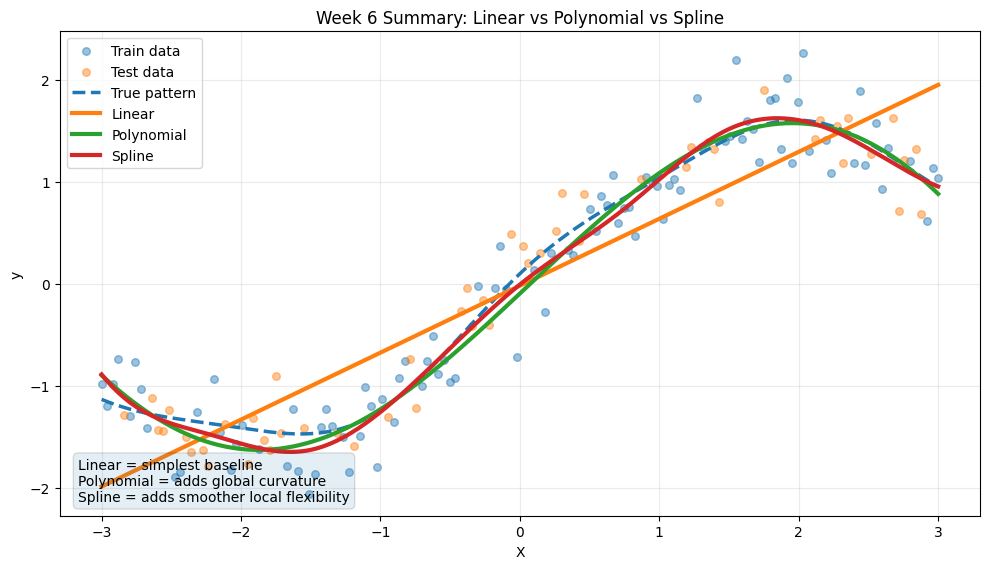

In [4]:
plt.figure(figsize = (10 , 5.8))
plt.scatter(X_train , y_train , alpha = 0.45 , s = 30 , label = "Train data")
plt.scatter(X_test , y_test , alpha = 0.45 , s = 30 , label = "Test data")
plt.plot(x_grid , y_true_grid , linestyle = "--" , linewidth = 2.5 , label = "True pattern")
for name , pred in grid_predictions.items():
    plt.plot(x_grid , pred , linewidth = 3 , label = name)
plt.title("Week 6 Summary: Linear vs Polynomial vs Spline")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(alpha = 0.25)
plt.legend(loc = "upper left")
plt.text(
    0.02 , 0.03 ,
    "Linear = simplest baseline\nPolynomial = adds global curvature\nSpline = adds smoother local flexibility" ,
    transform = plt.gca().transAxes , bbox = dict(boxstyle = "round , pad = 0.35" , alpha = 0.12)
)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Performance Comparison Across Model Families')

Text(0, 0.5, 'MSE')

Text(0.5, 0, 'Model')

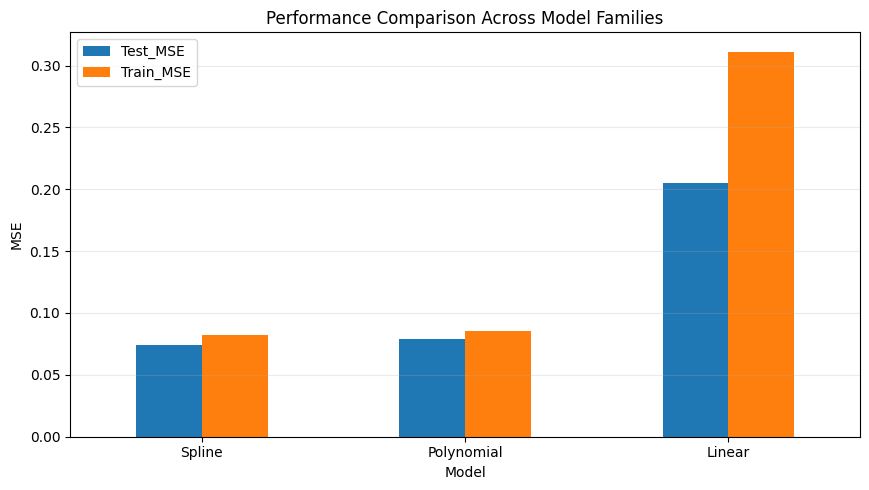

In [5]:
plot_df = results_df.set_index("Model")[["Test_MSE" , "Train_MSE"]]
ax = plot_df.plot(kind = "bar" , figsize = (8.8 , 5) , rot = 0)
ax.set_title("Performance Comparison Across Model Families")
ax.set_ylabel("MSE")
ax.set_xlabel("Model")
ax.grid(axis = "y" , alpha = 0.25)
plt.tight_layout()
plt.show()

In [6]:
print("============================= Week 6 Summary =============================")
print(results_df.round(3).to_string(index = False))
print("\nQuick decision guide:")
print("- Start with Linear when the relationship is roughly straight and you want a simple baseline.")
print("- Use Polynomial when you want a simple nonlinear upgrade and the curvature is smooth.")
print("- Use Spline when you want nonlinear flexibility without forcing one global polynomial.")
print("- Prefer the model that improves test performance, not just training fit.")
print("\nRemember:")
print("Nonlinear models help only when the added flexibility captures signal better than noise.")

============================= Week 6 Summary =============================
     Model  Train_MSE  Test_MSE  Test_R2                     Best_Use
    Spline      0.082     0.074    0.950 Controlled local flexibility
Polynomial      0.085     0.079    0.947      Simple smooth curvature
    Linear      0.311     0.205    0.862       Straight-line baseline

Quick decision guide:
- Start with Linear when the relationship is roughly straight and you want a simple baseline.
- Use Polynomial when you want a simple nonlinear upgrade and the curvature is smooth.
- Use Spline when you want nonlinear flexibility without forcing one global polynomial.
- Prefer the model that improves test performance, not just training fit.

Remember:
Nonlinear models help only when the added flexibility captures signal better than noise.
